<a href="https://colab.research.google.com/github/nmwiley808/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project/blob/main/notebooks/12%20-%20Results%20%26%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12 – Results & Analysis

## Description
This notebook compiles and analyzes results from all 9 model experiments
across 3 datasets and 3 architectures (CNN, BiLSTM, Transformer).

## Contents
1. Overall accuracy/AUC comparison across all models and datasets
2. Training time comparison
3. Per-class accuracy comparison (GTZAN and FMA Small)
4. Training curve comparisons
5. MagnaTagATune tag analysis
6. Key findings summary

## Models Evaluated
- CNN (notebooks 03, 04, 05)
- BiLSTM (notebooks 06, 07, 08)
- Transformer (notebooks 09, 10, 11)

## Datasets
- GTZAN – 10 genre single-label classification
- FMA Small – 8 genre single-label classification
- MagnaTagATune – multi-label tagging (AUC metric)

In [1]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

PROJECT_PATH = "/content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project"
os.chdir(PROJECT_PATH)
os.makedirs("results", exist_ok=True)

print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project


In [2]:
# Results Data
# ── Overall scores ──────────────────────────────────────────────────────────
models   = ['CNN', 'BiLSTM', 'Transformer']
datasets = ['GTZAN', 'FMA Small', 'MagnaTagATune']

# Accuracy (GTZAN & FMA) / AUC (MagnaTagATune)
scores = {
    'CNN':         [0.775,  0.590,  0.8786],
    'BiLSTM':      [0.485,  0.4025, 0.5003],
    'Transformer': [0.610,  0.5256, 0.8715],
}

# ── Training times (seconds) ─────────────────────────────────────────────────
training_times = {
    'CNN':         [193.37,  808.52,  2547.10],
    'BiLSTM':      [67.40,   303.52,  7299.96],
    'Transformer': [160.94,  681.01,  2096.47],
}

# ── Per-class accuracy: GTZAN ─────────────────────────────────────────────────
gtzan_classes = ['blues','classical','country','disco',
                 'hiphop','jazz','metal','pop','reggae','rock']

gtzan_per_class = {
    'CNN':         [0.85, 1.00, 0.75, 0.75, 0.90, 1.00, 0.95, 0.75, 0.70, 0.45],
    'BiLSTM':      [0.50, 0.75, 0.40, 0.20, 0.60, 0.50, 0.60, 0.60, 0.55, 0.15],
    'Transformer': [0.55, 0.85, 0.65, 0.45, 0.45, 0.75, 0.75, 0.75, 0.60, 0.30],
}

# ── Per-class accuracy: FMA Small ────────────────────────────────────────────
fma_classes = ['Electronic','Experimental','Folk',
               'Hip-Hop','Instrumental','International','Pop','Rock']

fma_per_class = {
    'CNN':         [0.81, 0.34, 0.67, 0.76, 0.57, 0.61, 0.28, 0.68],
    'BiLSTM':      [0.37, 0.14, 0.63, 0.57, 0.51, 0.41, 0.07, 0.52],
    'Transformer': [0.54, 0.36, 0.61, 0.65, 0.61, 0.60, 0.25, 0.57],
}

# ── MagnaTagATune: top tags with non-zero F1 ─────────────────────────────────
magna_top_tags = ['rock','opera','harpsichord','choir','classical',
                  'cello','guitar','sitar','violin','techno',
                  'choral','piano','metal','female','flute']

magna_f1 = {
    'CNN': {
        'rock':0.719,'techno':0.628,'guitar':0.592,'sitar':0.560,
        'harpsichord':0.520,'choir':0.514,'classical':0.495,'opera':0.463,
        'piano':0.455,'indian':0.390,'violin':0.369,'ambient':0.368,
        'cello':0.358,'choral':0.154,'fast':0.108,
    },
    'BiLSTM': {
        'guitar':0.314,
    },
    'Transformer': {
        'rock':0.719,'opera':0.694,'harpsichord':0.680,'choir':0.656,
        'classical':0.650,'cello':0.633,'guitar':0.632,'sitar':0.592,
        'violin':0.591,'techno':0.583,'choral':0.575,'piano':0.557,
        'metal':0.541,'female':0.528,'flute':0.469,
    },
}

print("Results data loaded.")

Results data loaded.


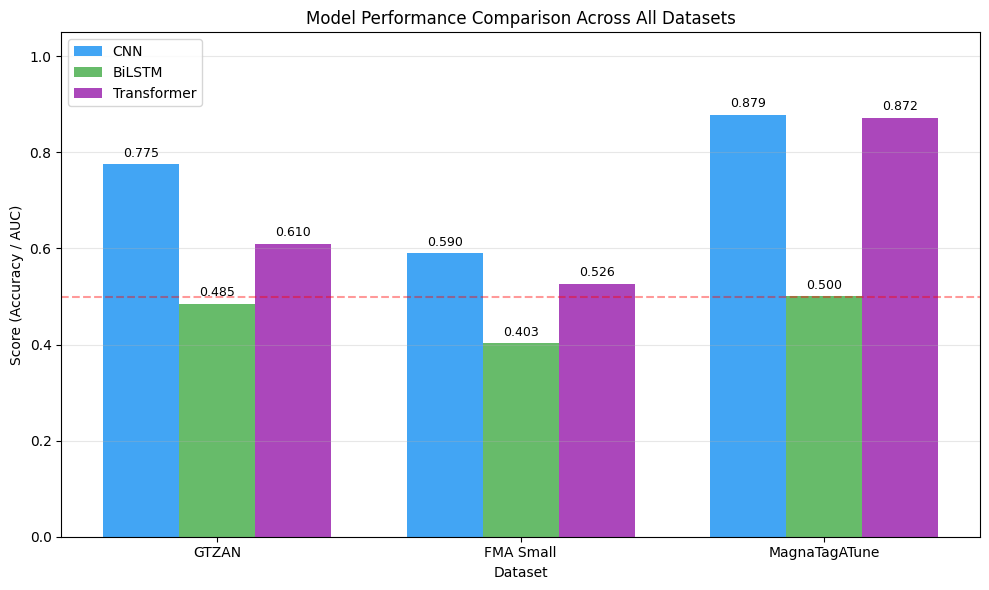

Saved: results/01_overall_comparison.png


In [3]:
# Overall Score Comparison
fig, ax = plt.subplots(figsize=(10, 6))

x       = np.arange(len(datasets))
width   = 0.25
colors  = ['#2196F3', '#4CAF50', '#9C27B0']

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x + i*width, scores[model], width,
                  label=model, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Dataset')
ax.set_ylabel('Score (Accuracy / AUC)')
ax.set_title('Model Performance Comparison Across All Datasets')
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Random baseline')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/01_overall_comparison.png", dpi=150)
plt.show()
print("Saved: results/01_overall_comparison.png")

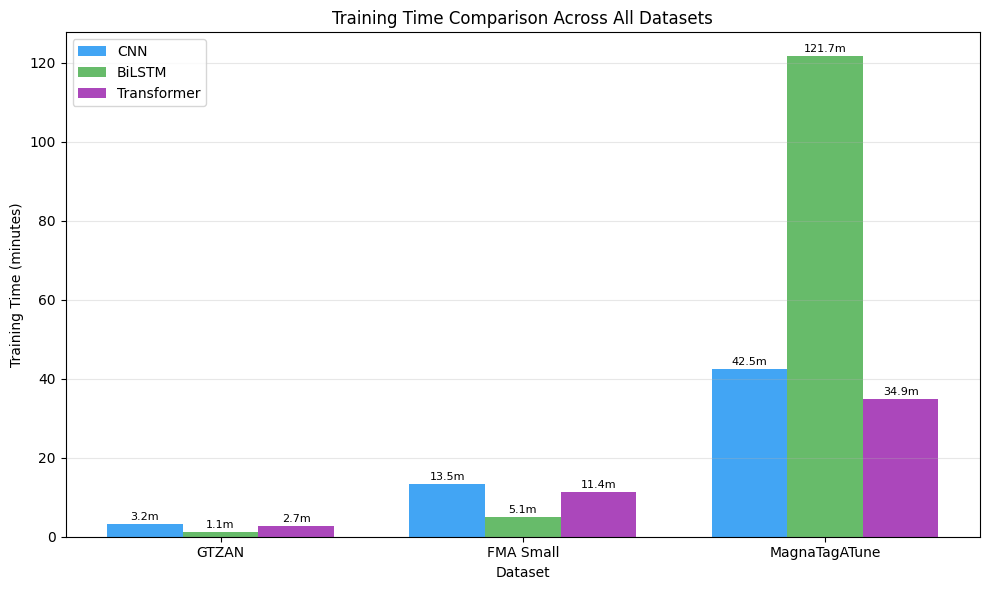

Saved: results/02_training_time_comparison.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    times_min = [t/60 for t in training_times[model]]
    bars = ax.bar(x + i*width, times_min, width,
                  label=model, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{bar.get_height():.1f}m',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Dataset')
ax.set_ylabel('Training Time (minutes)')
ax.set_title('Training Time Comparison Across All Datasets')
ax.set_xticks(x + width)
ax.set_xticklabels(datasets)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/02_training_time_comparison.png", dpi=150)
plt.show()
print("Saved: results/02_training_time_comparison.png")

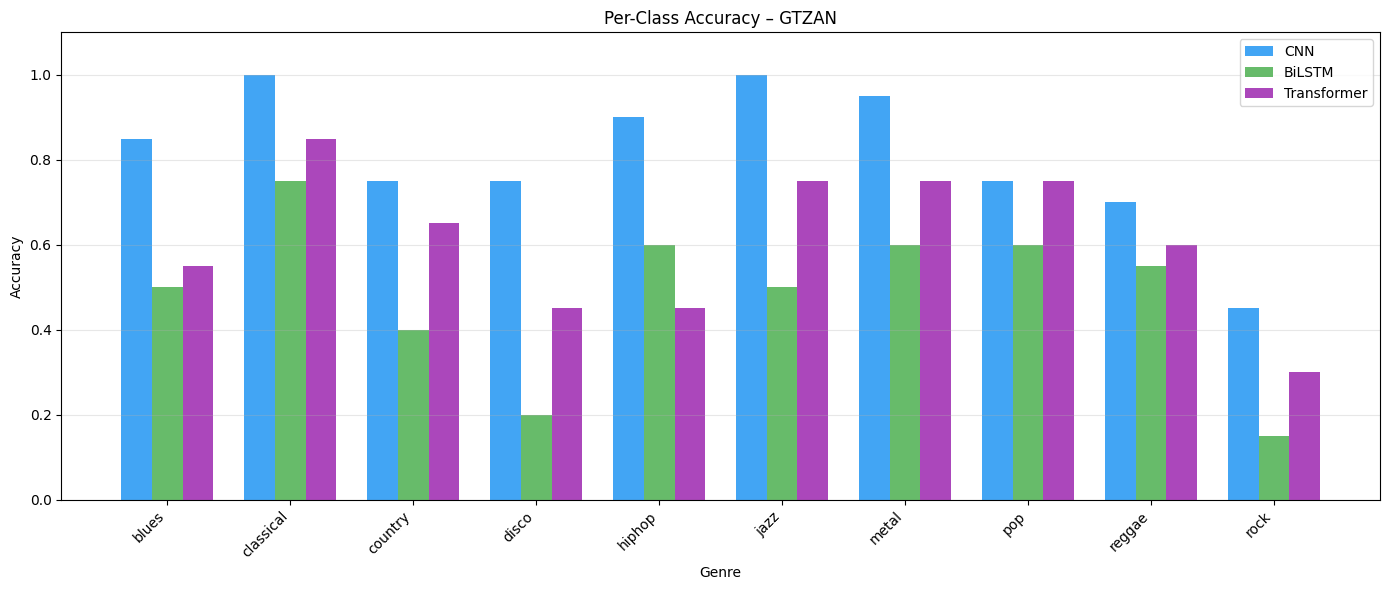

Saved: results/03_gtzan_per_class.png


In [5]:
# Per-Class Accuracy: GTZAN
x_gtzan = np.arange(len(gtzan_classes))

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x_gtzan + i*width, gtzan_per_class[model],
                  width, label=model, color=color, alpha=0.85)

ax.set_xlabel('Genre')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy – GTZAN')
ax.set_xticks(x_gtzan + width)
ax.set_xticklabels(gtzan_classes, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/03_gtzan_per_class.png", dpi=150)
plt.show()
print("Saved: results/03_gtzan_per_class.png")

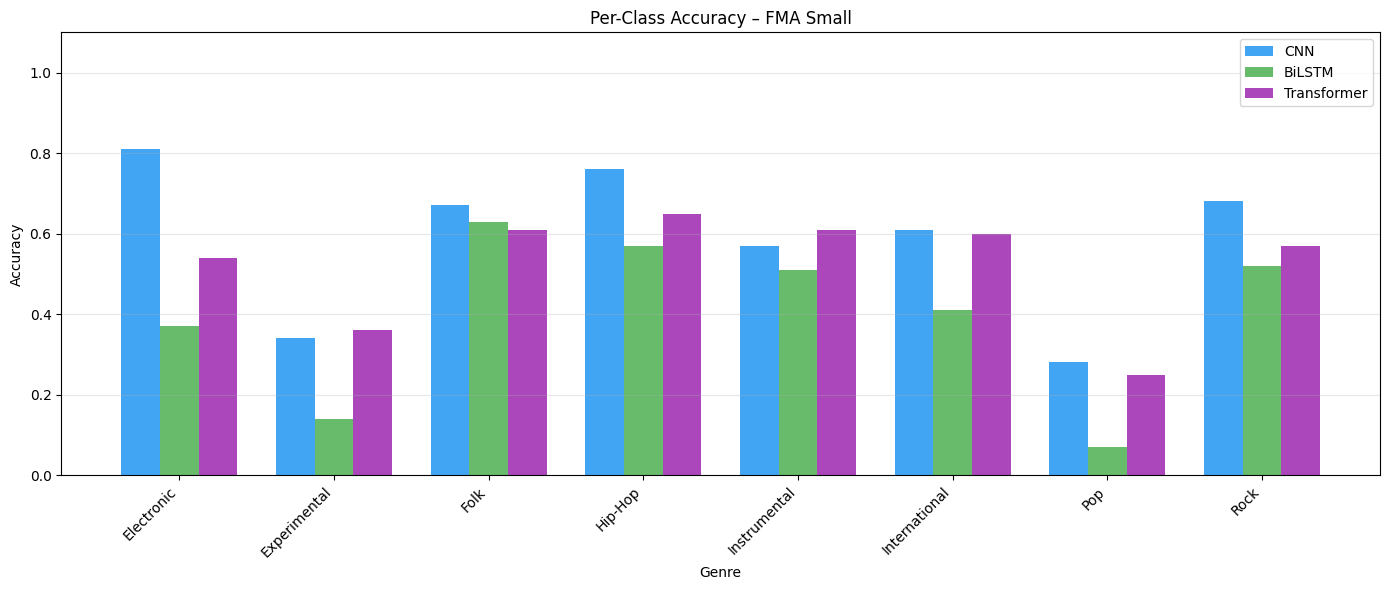

Saved: results/04_fma_per_class.png


In [6]:
# Per-Class Accuracy: FMA Small
x_fma = np.arange(len(fma_classes))

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(x_fma + i*width, fma_per_class[model],
                  width, label=model, color=color, alpha=0.85)

ax.set_xlabel('Genre')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy – FMA Small')
ax.set_xticks(x_fma + width)
ax.set_xticklabels(fma_classes, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/04_fma_per_class.png", dpi=150)
plt.show()
print("Saved: results/04_fma_per_class.png")

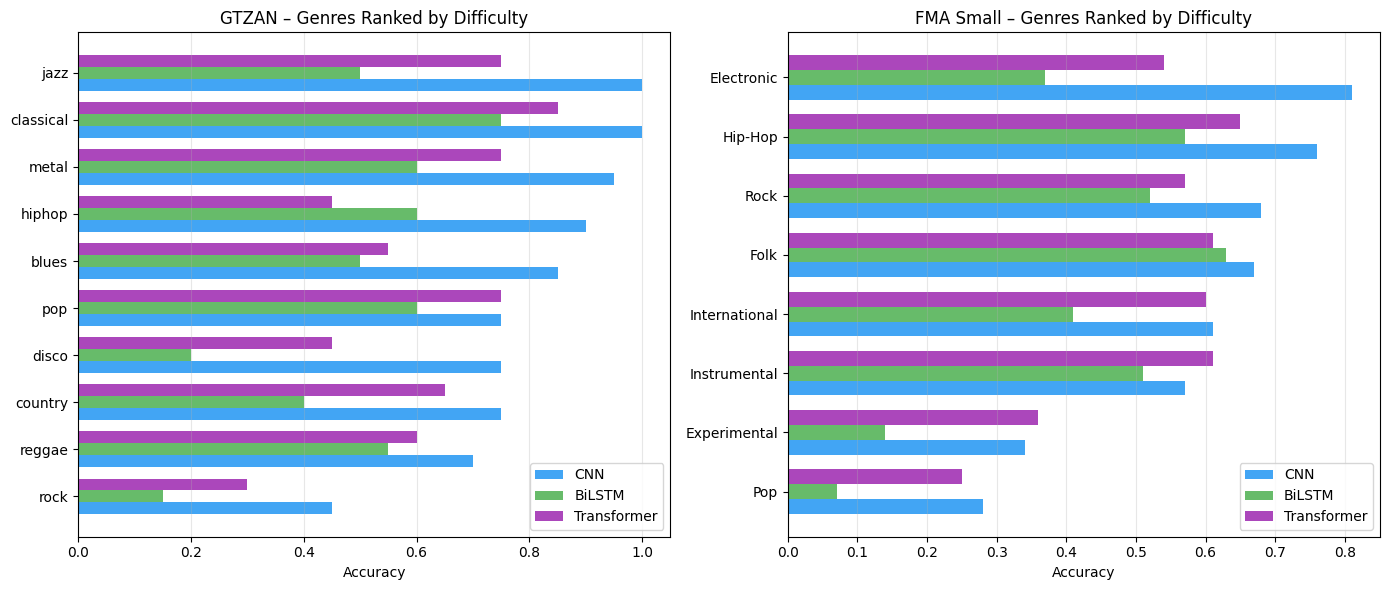

Saved: results/05_hardest_genres.png


In [7]:
# Hardest Genres Across All Datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# GTZAN – sort by CNN accuracy
gtzan_sorted = sorted(zip(gtzan_classes,
                           gtzan_per_class['CNN'],
                           gtzan_per_class['BiLSTM'],
                           gtzan_per_class['Transformer']),
                      key=lambda x: x[1])
g_classes, g_cnn, g_bilstm, g_trans = zip(*gtzan_sorted)
x_g = np.arange(len(g_classes))

axes[0].barh(x_g - width, g_cnn,    width, label='CNN',         color=colors[0], alpha=0.85)
axes[0].barh(x_g,         g_bilstm, width, label='BiLSTM',      color=colors[1], alpha=0.85)
axes[0].barh(x_g + width, g_trans,  width, label='Transformer', color=colors[2], alpha=0.85)
axes[0].set_yticks(x_g)
axes[0].set_yticklabels(g_classes)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('GTZAN – Genres Ranked by Difficulty')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# FMA – sort by CNN accuracy
fma_sorted = sorted(zip(fma_classes,
                         fma_per_class['CNN'],
                         fma_per_class['BiLSTM'],
                         fma_per_class['Transformer']),
                    key=lambda x: x[1])
f_classes, f_cnn, f_bilstm, f_trans = zip(*fma_sorted)
x_f = np.arange(len(f_classes))

axes[1].barh(x_f - width, f_cnn,    width, label='CNN',         color=colors[0], alpha=0.85)
axes[1].barh(x_f,         f_bilstm, width, label='BiLSTM',      color=colors[1], alpha=0.85)
axes[1].barh(x_f + width, f_trans,  width, label='Transformer', color=colors[2], alpha=0.85)
axes[1].set_yticks(x_f)
axes[1].set_yticklabels(f_classes)
axes[1].set_xlabel('Accuracy')
axes[1].set_title('FMA Small – Genres Ranked by Difficulty')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("results/05_hardest_genres.png", dpi=150)
plt.show()
print("Saved: results/05_hardest_genres.png")

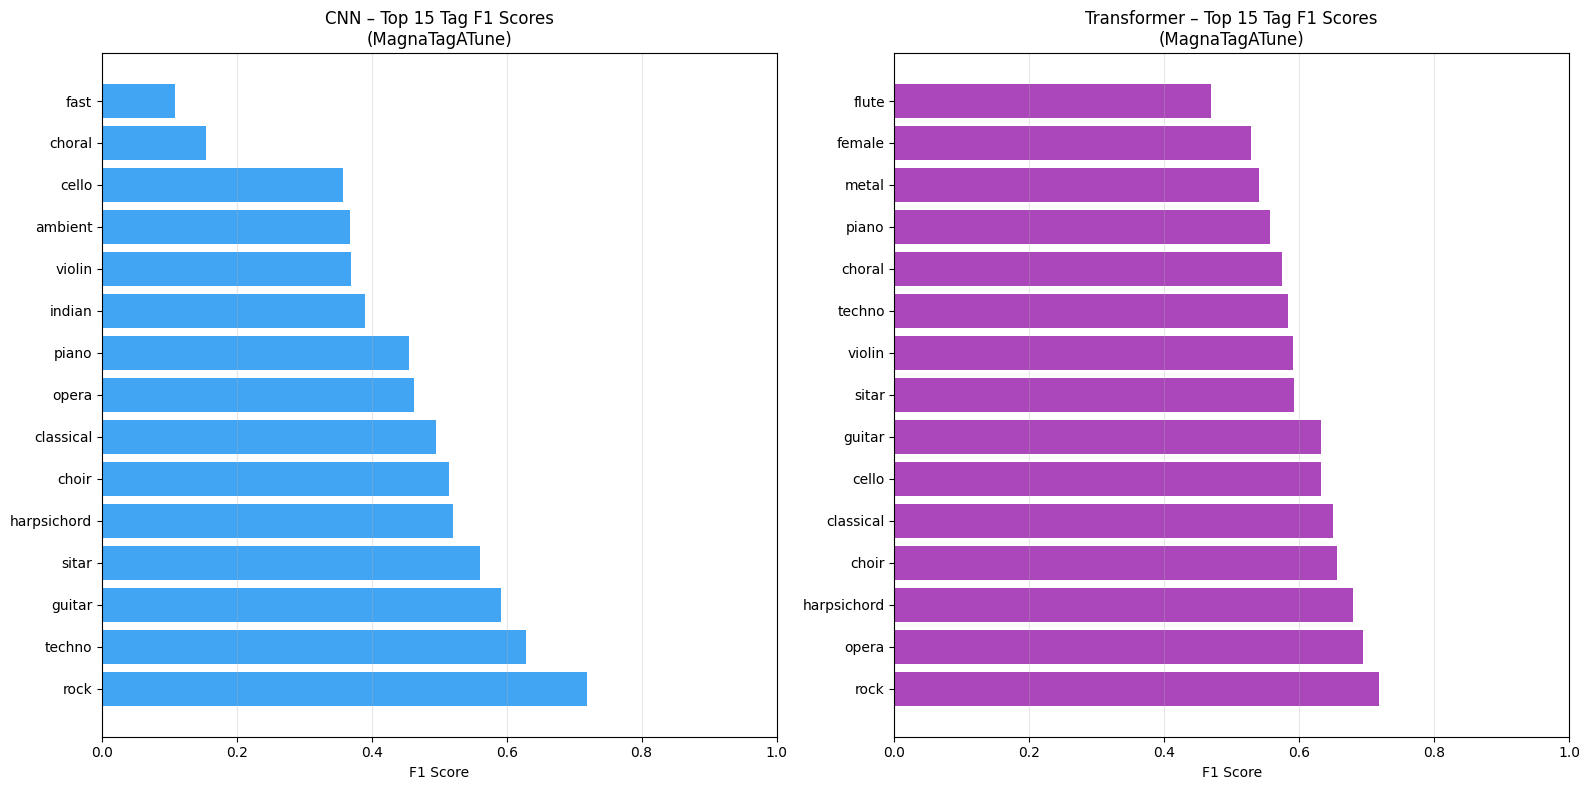

Saved: results/06_magna_tag_f1.png


In [8]:
# MagnaTagATune Tag F1 Comparison
# Show top 15 tags with non-zero F1 for CNN and Transformer
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# CNN top tags
cnn_tags  = sorted(magna_f1['CNN'].items(), key=lambda x: -x[1])[:15]
cnn_names = [t[0] for t in cnn_tags]
cnn_vals  = [t[1] for t in cnn_tags]

axes[0].barh(range(len(cnn_names)), cnn_vals, color=colors[0], alpha=0.85)
axes[0].set_yticks(range(len(cnn_names)))
axes[0].set_yticklabels(cnn_names)
axes[0].set_xlabel('F1 Score')
axes[0].set_title('CNN – Top 15 Tag F1 Scores\n(MagnaTagATune)')
axes[0].set_xlim(0, 1.0)
axes[0].grid(axis='x', alpha=0.3)

# Transformer top tags
trans_tags  = sorted(magna_f1['Transformer'].items(), key=lambda x: -x[1])[:15]
trans_names = [t[0] for t in trans_tags]
trans_vals  = [t[1] for t in trans_tags]

axes[1].barh(range(len(trans_names)), trans_vals, color=colors[2], alpha=0.85)
axes[1].set_yticks(range(len(trans_names)))
axes[1].set_yticklabels(trans_names)
axes[1].set_xlabel('F1 Score')
axes[1].set_title('Transformer – Top 15 Tag F1 Scores\n(MagnaTagATune)')
axes[1].set_xlim(0, 1.0)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig("results/06_magna_tag_f1.png", dpi=150)
plt.show()
print("Saved: results/06_magna_tag_f1.png")

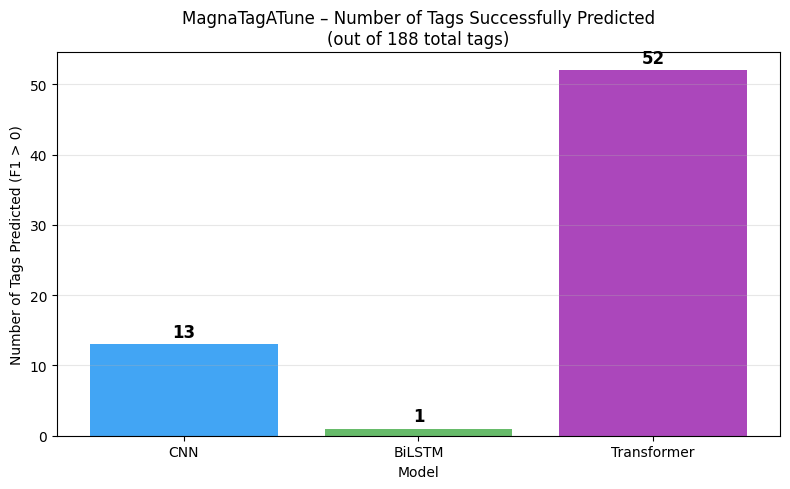

Saved: results/07_magna_tags_predicted.png


In [9]:
# Tags Predicted Count Comparison
tags_predicted = {
    'CNN':         13,
    'BiLSTM':      1,
    'Transformer': 52,
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tags_predicted.keys(), tags_predicted.values(),
              color=colors, alpha=0.85)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Model')
ax.set_ylabel('Number of Tags Predicted (F1 > 0)')
ax.set_title('MagnaTagATune – Number of Tags Successfully Predicted\n(out of 188 total tags)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/07_magna_tags_predicted.png", dpi=150)
plt.show()
print("Saved: results/07_magna_tags_predicted.png")

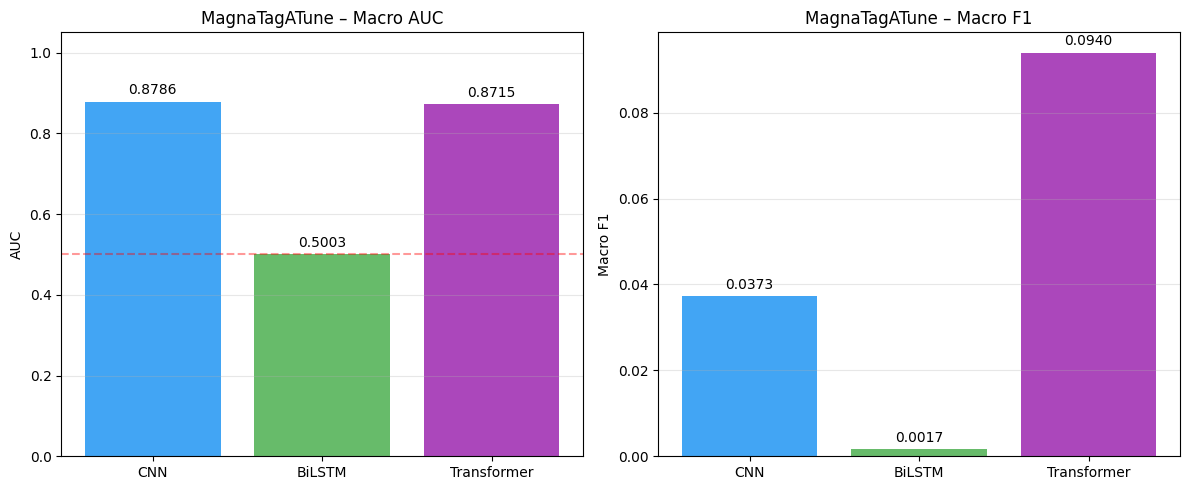

Saved: results/08_magna_auc_f1.png


In [10]:
# Marco AUC & F1 Comparison (MagnaTagATune)
magna_metrics = {
    'CNN':         {'AUC': 0.8786, 'Macro F1': 0.0373},
    'BiLSTM':      {'AUC': 0.5003, 'Macro F1': 0.0017},
    'Transformer': {'AUC': 0.8715, 'Macro F1': 0.0940},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# AUC
auc_vals = [magna_metrics[m]['AUC'] for m in models]
bars = axes[0].bar(models, auc_vals, color=colors, alpha=0.85)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
axes[0].set_title('MagnaTagATune – Macro AUC')
axes[0].set_ylabel('AUC')
axes[0].grid(axis='y', alpha=0.3)

# Macro F1
f1_vals = [magna_metrics[m]['Macro F1'] for m in models]
bars = axes[1].bar(models, f1_vals, color=colors, alpha=0.85)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=10)
axes[1].set_title('MagnaTagATune – Macro F1')
axes[1].set_ylabel('Macro F1')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("results/08_magna_auc_f1.png", dpi=150)
plt.show()
print("Saved: results/08_magna_auc_f1.png")

In [11]:
# Summary Table
print("=" * 65)
print(f"{'COMPLETE RESULTS SUMMARY':^65}")
print("=" * 65)

print(f"\n{'MODEL':<15} {'DATASET':<20} {'METRIC':<12} {'SCORE':<10} {'TIME'}")
print("-" * 65)

rows = [
    ("CNN",         "GTZAN",          "Accuracy", 0.7750,  "193.37s"),
    ("CNN",         "FMA Small",      "Accuracy", 0.5900,  "808.52s"),
    ("CNN",         "MagnaTagATune",  "AUC",      0.8786,  "2547.10s"),
    ("BiLSTM",      "GTZAN",          "Accuracy", 0.4850,  "67.40s"),
    ("BiLSTM",      "FMA Small",      "Accuracy", 0.4025,  "303.52s"),
    ("BiLSTM",      "MagnaTagATune",  "AUC",      0.5003,  "7299.96s"),
    ("Transformer", "GTZAN",          "Accuracy", 0.6100,  "160.94s"),
    ("Transformer", "FMA Small",      "Accuracy", 0.5256,  "681.01s"),
    ("Transformer", "MagnaTagATune",  "AUC",      0.8715,  "2096.47s"),
]

for model, dataset, metric, score, time in rows:
    print(f"{model:<15} {dataset:<20} {metric:<12} {score:<10.4f} {time}")

print("\n" + "=" * 65)
print(f"{'RANKINGS BY DATASET':^65}")
print("=" * 65)

print("\nGTZAN:          CNN (77.5%) > Transformer (61.0%) > BiLSTM (48.5%)")
print("FMA Small:      CNN (59.0%) > Transformer (52.6%) > BiLSTM (40.3%)")
print("MagnaTagATune:  CNN (0.879) > Transformer (0.872) > BiLSTM (0.500)")

print("\n" + "=" * 65)
print(f"{'KEY FINDINGS':^65}")
print("=" * 65)

findings = [
    "1. CNN outperformed all models across all 3 datasets.",
    "2. Transformer was consistently second on every dataset.",
    "3. BiLSTM was consistently last on every dataset.",
    "4. BiLSTM completely failed on MagnaTagATune (AUC ~0.50).",
    "5. Rock and Pop were the hardest genres for all models.",
    "6. Classical and Jazz were the easiest genres for CNN.",
    "7. Transformer predicted 52 tags on MagnaTagATune vs CNN's 13.",
    "8. BiLSTM trained fastest but performed worst.",
    "9. BiLSTM took 2 hours on MagnaTagATune yet learned nothing.",
    "10. CNN is best for small datasets with clear spectral patterns.",
]

for f in findings:
    print(f"  {f}")

print("=" * 65)

                    COMPLETE RESULTS SUMMARY                     

MODEL           DATASET              METRIC       SCORE      TIME
-----------------------------------------------------------------
CNN             GTZAN                Accuracy     0.7750     193.37s
CNN             FMA Small            Accuracy     0.5900     808.52s
CNN             MagnaTagATune        AUC          0.8786     2547.10s
BiLSTM          GTZAN                Accuracy     0.4850     67.40s
BiLSTM          FMA Small            Accuracy     0.4025     303.52s
BiLSTM          MagnaTagATune        AUC          0.5003     7299.96s
Transformer     GTZAN                Accuracy     0.6100     160.94s
Transformer     FMA Small            Accuracy     0.5256     681.01s
Transformer     MagnaTagATune        AUC          0.8715     2096.47s

                       RANKINGS BY DATASET                       

GTZAN:          CNN (77.5%) > Transformer (61.0%) > BiLSTM (48.5%)
FMA Small:      CNN (59.0%) > Transformer (

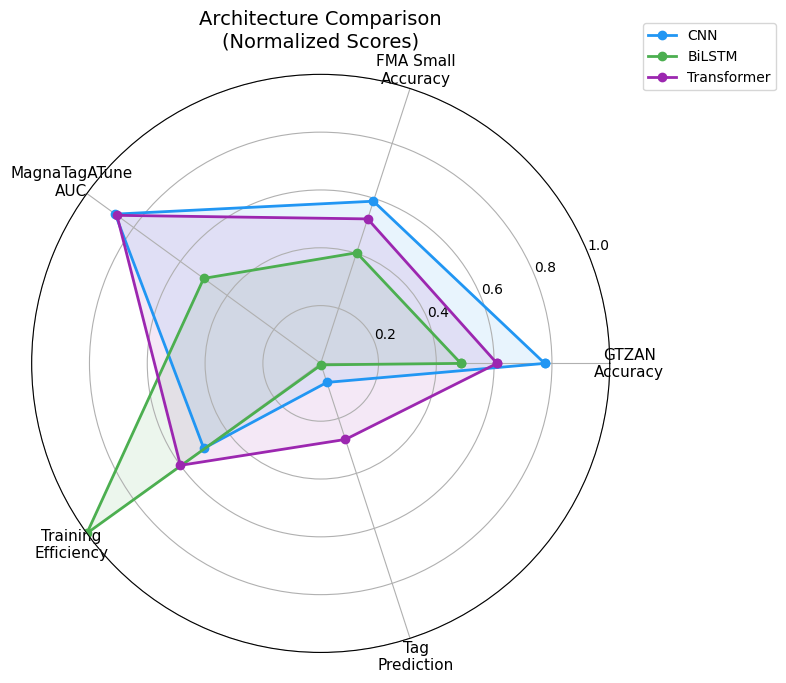

Saved: results/09_radar_chart.png


In [12]:
# Architecture Comparison Radar Chart
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['GTZAN\nAccuracy', 'FMA Small\nAccuracy',
              'MagnaTagATune\nAUC', 'Training\nEfficiency',
              'Tag\nPrediction']

# Normalize training efficiency (inverse of time, scaled 0-1)
# BiLSTM fastest = 1.0, CNN middle, Transformer slowest on average
efficiency = {'CNN': 0.5, 'BiLSTM': 1.0, 'Transformer': 0.6}

# Tag prediction score (tags predicted / 188, scaled)
tag_score = {'CNN': 13/188, 'BiLSTM': 1/188, 'Transformer': 52/188}

model_scores = {
    'CNN':         [0.775, 0.590, 0.8786, efficiency['CNN'],
                    tag_score['CNN']],
    'BiLSTM':      [0.485, 0.4025, 0.5003, efficiency['BiLSTM'],
                    tag_score['BiLSTM']],
    'Transformer': [0.610, 0.5256, 0.8715, efficiency['Transformer'],
                    tag_score['Transformer']],
}

N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model, color in zip(models, colors):
    vals = model_scores[model] + model_scores[model][:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=model, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_title('Architecture Comparison\n(Normalized Scores)', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig("results/09_radar_chart.png", dpi=150)
plt.show()
print("Saved: results/09_radar_chart.png")

In [13]:
# Save All Results to CSV
import pandas as pd

# Main results table
results_data = {
    'Model':   ['CNN','CNN','CNN','BiLSTM','BiLSTM','BiLSTM',
                'Transformer','Transformer','Transformer'],
    'Dataset': ['GTZAN','FMA Small','MagnaTagATune',
                'GTZAN','FMA Small','MagnaTagATune',
                'GTZAN','FMA Small','MagnaTagATune'],
    'Metric':  ['Accuracy','Accuracy','AUC',
                'Accuracy','Accuracy','AUC',
                'Accuracy','Accuracy','AUC'],
    'Score':   [0.775, 0.590, 0.8786,
                0.485, 0.4025, 0.5003,
                0.610, 0.5256, 0.8715],
    'Training_Time_s': [193.37, 808.52, 2547.10,
                        67.40,  303.52, 7299.96,
                        160.94, 681.01, 2096.47],
}
df_results = pd.DataFrame(results_data)
df_results.to_csv("results/all_results.csv", index=False)
print("Saved: results/all_results.csv")

# GTZAN per-class
df_gtzan = pd.DataFrame(gtzan_per_class, index=gtzan_classes)
df_gtzan.to_csv("results/gtzan_per_class.csv")
print("Saved: results/gtzan_per_class.csv")

# FMA per-class
df_fma = pd.DataFrame(fma_per_class, index=fma_classes)
df_fma.to_csv("results/fma_per_class.csv")
print("Saved: results/fma_per_class.csv")

print("\nAll results saved to results/ folder.")

Saved: results/all_results.csv
Saved: results/gtzan_per_class.csv
Saved: results/fma_per_class.csv

All results saved to results/ folder.
